In [451]:
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower
import statsmodels.formula.api as smf
from scipy import stats
import numpy as np
import pandas as pd

df1 = pd.read_csv('data/simulated_ab_test_data_A1.csv')
df2 = pd.read_csv('data/simulated_ab_test_data_B1.csv')
df3 = pd.read_csv('data/simulated_ab_test_data_C1.csv')

for tag,dataframe in zip(['First', 'Second', 'Third'], [df1, df2, df3]):
    dataframe['week_number'] = tag

DF_ANALYSIS = pd.concat([df1, df2, df3], ignore_index=True)

# df1.translate_click.mean(),df2.translate_click.mean(),df3.translate_click.mean()
DF_ANALYSIS.info()

<class 'pandas.DataFrame'>
RangeIndex: 6122 entries, 0 to 6121
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   group              6122 non-null   str    
 1   ctr                6122 non-null   float64
 2   interactions       6122 non-null   float64
 3   dwell_time         6122 non-null   float64
 4   latency            6122 non-null   float64
 5   translate_click    6122 non-null   float64
 6   first_action_time  6122 non-null   float64
 7   bounce             6122 non-null   float64
 8   gender             6122 non-null   str    
 9   browser_language   6122 non-null   str    
 10  week_number        6122 non-null   str    
dtypes: float64(7), str(4)
memory usage: 526.2 KB


In [452]:
class ABTest:
    def __init__(self, df, **kwargs):
        """
        ABTest class for binary KPIs (clicked or not).

        Parameters
        ----------
        df : pd.DataFrame
            The dataset containing the experiment results.
        kpi : str, optional
            Column name for the binary KPI (default is 'clicked').
        """
        self.iteration = 1
        self.df = df
        self.kpi = kwargs.get('kpi', 'translate_click')

    def append_data(self, new_df):
        self.iteration += 1
        self.df = pd.concat([self.df, new_df], ignore_index=True)

    def balance(self, feature: str):
        """
        Show distribution of a feature across groups.
        """
        balance_table = pd.crosstab(self.df['group'], self.df[feature], normalize='index')
        display(balance_table)

    def are_we_underpowered(self, actual, required):
        difference = actual - required
        return 'underpowered' if difference < 0 else 'appropriately powered'

    def power_analysis(self, **kwargs):
        """
        Estimate whether the current sample size is sufficient for detecting a minimum detectable effect (MDE).

        Default mde, alpha, power are respectively 0.02, 0.05, 0.80
        """
        baseline_rate = self.df[self.kpi].mean()
        mde_absolute = kwargs.get('mde', 0.03)
        expected_treatment = baseline_rate + mde_absolute
        alpha = kwargs.get('alpha', 0.05)
        power = kwargs.get('power', 0.80)

        effect_size = proportion_effectsize(baseline_rate, expected_treatment)

        analysis = NormalIndPower()
        required_n = analysis.solve_power(
            effect_size=effect_size,
            power=power,
            alpha=alpha,
            ratio=1
        )

        actual_n = self.df['group'].value_counts().min()
        print(
            f"Required sample size per group: {np.ceil(required_n)}\n"
            f"Actual sample size per group: {np.ceil(actual_n)}\n"
            f"Experiment is {self.are_we_underpowered(actual_n, required_n)}"
        )

    def welch_t_test(self, **kwargs):
        """
        Perform Welch's t-test on binary KPI between groups A and B.
        """
        control = self.df[self.df['group'] == 'A'][self.kpi]
        treatment = self.df[self.df['group'] == 'B'][self.kpi]
        doprint = kwargs.get('doprint', False)

        t_stat, p_value = stats.ttest_ind(
            treatment,
            control,
            equal_var=False  # Welch
        )

        if doprint:
            print("t-stat:", t_stat)
            print("p-value:", p_value)
        else: return treatment, control

    def lift_ci(self):
        """
        Compute the absolute lift (difference in proportion) and 95% confidence interval.
        """
        treatment, control = self.welch_t_test()
        diff = treatment.mean() - control.mean()

        se = np.sqrt(
            treatment.var(ddof=1)/len(treatment) +
            control.var(ddof=1)/len(control)
        )

        ci_low = diff - 1.96 * se
        ci_high = diff + 1.96 * se

        print(f"Lift: {round(diff*100, 2)}%")
        print(f"95% Confidence Interval: [{ci_low:.4f}, {ci_high:.4f}]")

    def regression_rob_check(self):
        """
        Fit a robust OLS regression for the KPI on group and other covariates.
        """
        formula = f"{self.kpi} ~ C(group) + C(gender)"
        if self.iteration > 1:
            formula += " + C(week_number)"

        model = smf.ols(formula=formula, data=self.df).fit(cov_type='HC3')
        print(model.summary())

In [453]:
ab_tester = ABTest(df1)
# Day1 workflow:
# ab_tester.power_analysis()
# ab_tester.welch_t_test()
# ab_tester.lift_ci()
# ab_tester.regression_rob_check()

In [454]:
ab_tester.df.describe(include='all')

,group,ctr,interactions,dwell_time,latency,translate_click,first_action_time,bounce,gender,browser_language,week_number
count,3406,3406.000000,3406.000000,3406.000000,3406.000000,3406.000000,3406.000000,3406.000000,3406,3406,3406
unique,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,5,1
top,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Male,Portuguese,First
freq,1703,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1159,1078,3406
mean,NaN,0.056239,18.673288,29.914121,290.039865,0.175573,5.091872,0.416031,NaN,NaN,NaN
std,NaN,0.039497,12.163880,23.777092,22.031704,0.380512,1.167499,0.492971,NaN,NaN,NaN
min,NaN,0.000000,2.536717,3.047405,211.536240,0.000000,1.409046,0.000000,NaN,NaN,NaN
25%,NaN,0.024422,9.588989,12.088526,275.425970,0.000000,4.272383,0.000000,NaN,NaN,NaN
50%,NaN,0.057110,14.987426,22.217747,289.881440,0.000000,5.101003,0.000000,NaN,NaN,NaN
75%,NaN,0.083958,24.905204,41.595146,305.149998,0.000000,5.873244,1.000000,NaN,NaN,NaN


In [455]:
ab_tester.df.head()

,group,ctr,interactions,dwell_time,latency,translate_click,first_action_time,bounce,gender,browser_language,week_number
0,A,0.056525,13.591245,10.956391,269.125246,0.0,5.547722,0.0,Other,Spanish,First
1,A,0.059077,8.885421,7.534534,316.916903,0.0,4.223827,0.0,Male,Brazilian Portuguese,First
2,A,0.082876,16.143445,17.955384,309.392938,0.0,4.222030,1.0,Male,Brazilian Portuguese,First
3,A,0.082344,9.088853,9.848331,275.087513,1.0,6.210365,0.0,Male,French,First
4,A,0.082163,11.520943,14.713234,286.636546,0.0,4.394706,0.0,Other,Portuguese,First


In [456]:
ab_tester.df.group.unique()

<StringArray>
['A', 'B']
Length: 2, dtype: str

In [457]:
#looking at mean, standard deviation CTR per group, as well as addressing potential sample ratio mismatch
group_summary = ab_tester.df.groupby('group')['translate_click'].agg(['mean', 'std', 'count'])
control_mean = group_summary.loc['A', 'mean']
treatment_mean = group_summary.loc['B', 'mean']
display(group_summary)

,mean,std,count
group,,,
A,0.169701,0.375480,1703
B,0.181445,0.385499,1703


In [458]:
ab_tester.balance('gender')

gender,Female,Male,Other
group,,,
A,0.335291,0.334116,0.330593
B,0.320611,0.346447,0.332942


In [459]:
ab_tester.balance('browser_language')

browser_language,Brazilian Portuguese,English,French,Portuguese,Spanish
group,,,,,
A,0.314739,0.172049,0.054610,0.310628,0.147974
B,0.311803,0.141515,0.061656,0.322372,0.162654


In [460]:
baseline_ctr = control_mean
print("Baseline CTR:", baseline_ctr)

Baseline CTR: 0.16970052847915443


In [461]:
ab_tester.power_analysis()

Required sample size per group: 2687.0
Actual sample size per group: 1703
Experiment is underpowered


In [462]:
ab_tester.welch_t_test(doprint=True)

t-stat: 0.9005904983830877
p-value: 0.3678698416911733


In [463]:
ab_tester.lift_ci()

Lift: 1.17%
95% Confidence Interval: [-0.0138, 0.0373]


In [464]:
ab_tester.regression_rob_check()

                            OLS Regression Results                            
Dep. Variable:        translate_click   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.8091
Date:                Thu, 05 Mar 2026   Prob (F-statistic):              0.489
Time:                        23:15:03   Log-Likelihood:                -1540.2
No. Observations:                3406   AIC:                             3088.
Df Residuals:                    3402   BIC:                             3113.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.1591      0

In [465]:
# Day2 workflow:
# ab_tester.append_data(new data)
# ab_tester.power_analysis()
# ab_tester.welch_t_test(doprint=True)
# ab_tester.lift_ci()
# ab_tester.regression_rob_check()

In [466]:
ab_tester.append_data(df2)

In [467]:
ab_tester.power_analysis()

Required sample size per group: 2736.0
Actual sample size per group: 2382
Experiment is underpowered


In [468]:
ab_tester.welch_t_test(doprint=True)

t-stat: 1.1310049593892437
p-value: 0.2581100024551514


In [469]:
ab_tester.lift_ci()

Lift: 1.26%
95% Confidence Interval: [-0.0092, 0.0344]


In [470]:
ab_tester.regression_rob_check()

                            OLS Regression Results                            
Dep. Variable:        translate_click   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.7915
Date:                Thu, 05 Mar 2026   Prob (F-statistic):              0.530
Time:                        23:15:03   Log-Likelihood:                -2201.9
No. Observations:                4764   AIC:                             4414.
Df Residuals:                    4759   BIC:                             4446.
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [471]:
# Day3 workflow:
# ab_tester.append_data(new data)
# ab_tester.power_analysis()
# ab_tester.welch_t_test(doprint=True)
# ab_tester.lift_ci()
# ab_tester.regression_rob_check()

In [472]:
ab_tester.append_data(df3)

In [473]:
ab_tester.power_analysis()

Required sample size per group: 2749.0
Actual sample size per group: 3061
Experiment is appropriately powered


In [474]:
ab_tester.welch_t_test(doprint=True)

t-stat: 1.061447799981179
p-value: 0.28852834948704004


In [475]:
ab_tester.lift_ci()

Lift: 1.05%
95% Confidence Interval: [-0.0088, 0.0298]


In [476]:
ab_tester.regression_rob_check()

                            OLS Regression Results                            
Dep. Variable:        translate_click   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.6344
Date:                Thu, 05 Mar 2026   Prob (F-statistic):              0.674
Time:                        23:15:03   Log-Likelihood:                -2846.0
No. Observations:                6122   AIC:                             5704.
Df Residuals:                    6116   BIC:                             5744.
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

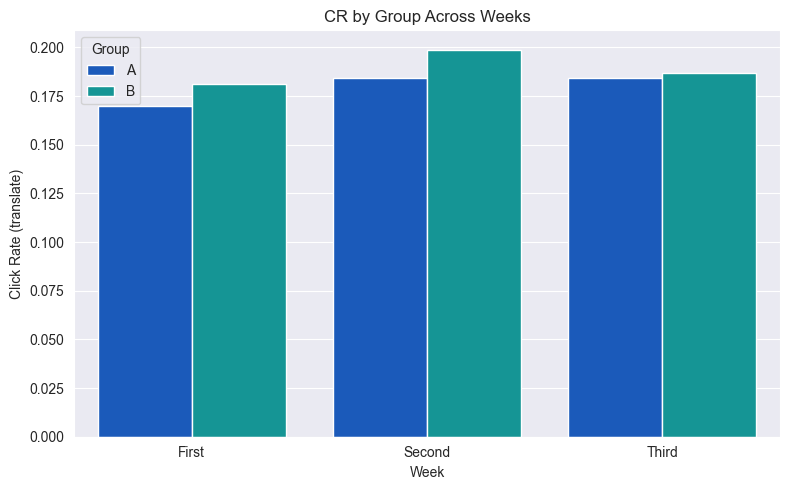

In [477]:
# Create the plot

DF_ANALYSIS = ab_tester.df

plt.figure(figsize=(8,5))
sns.barplot(
    data=DF_ANALYSIS,
    x='week_number',
    y='translate_click',
    hue='group',
    palette='winter',
    errorbar=None
)

#labels and title
plt.ylabel("Click Rate (translate)")
plt.xlabel("Week")
plt.title("CR by Group Across Weeks")
plt.legend(title='Group')

# Show plot
plt.tight_layout()
plt.show()